<a href="https://colab.research.google.com/github/eltongaspar/python/blob/Advpl/Aula_03_Aluno_MLP_Forward_Propagation_ProEducador.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 3 – Arquitetura MLP e Forward Propagation

**Curso:** Deep Learning e Inteligência Artificial Generativa Aplicada  
**Tema:** Camadas de entrada, ocultas e saída; arquitetura MLP; propagação direta (*forward propagation*).  

## Capacidades trabalhadas
- Construir redes neurais artificiais.

## Conhecimentos
- Camadas de entrada, ocultas e saída.
- Arquitetura MLP (*Multilayer Perceptron*).
- Forward propagation.

## Evidência de aprendizagem
Ao final da aula, o aluno deverá entregar um notebook funcional contendo a implementação de uma MLP simples e a interpretação do fluxo de propagação direta.

## 1. Situação-problema industrial da aula

Uma empresa industrial monitora motores elétricos por meio de sensores de:

- temperatura do motor;
- vibração;
- corrente elétrica.

O objetivo didático desta aula é entender como uma **rede neural MLP** recebe esses dados na **camada de entrada**, processa as informações em uma ou mais **camadas ocultas** e gera uma saída para indicar **risco de falha**.

Nesta aula, o foco principal **não é ainda treinar profundamente o modelo**, mas compreender a arquitetura e o caminho matemático dos dados dentro da rede neural.

In [1]:
# ============================================
# AULA 3 - VERSÃO ALUNO
# Complete os campos indicados com ________
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

np.random.seed(42)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Carregando o dataset simplificado

Complete a leitura do arquivo CSV para iniciar a análise.

In [3]:
# Complete o nome do arquivo CSV
df = pd.read_csv('/content/drive/MyDrive/Classroom/Deep Learning Pró Educador/dataset_aula3_mlp_forward_industrial.csv')

display(df.head())
print("\nDimensão do dataset:", df.shape)
print("\nDistribuição da classe alvo:")
print(df['risco_falha'].map({0:'Normal', 1:'Falha'}).value_counts())

,temperatura_motor_c,vibracao_mm_s,corrente_a,risco_falha
0,70.96,5.78,9.27,1
1,63.34,0.76,8.43,0
2,72.77,3.82,4.37,1
3,83.28,1.06,8.32,0
4,62.19,2.43,5.89,0



Dimensão do dataset: (220, 4)

Distribuição da classe alvo:
risco_falha
Normal    152
Falha      68
Name: count, dtype: int64


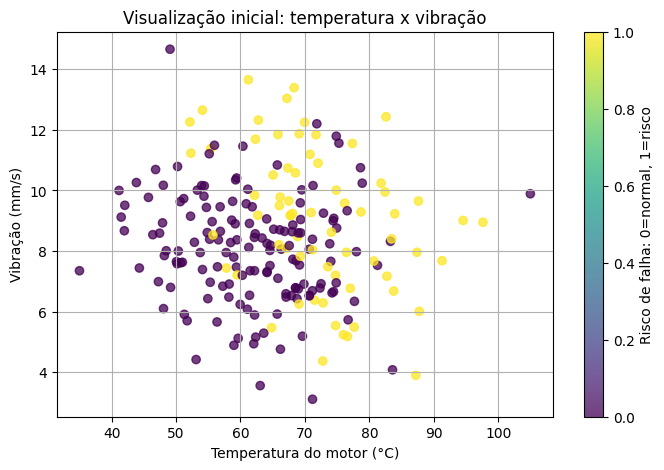

In [4]:
# Visualização inicial dos dados
plt.figure(figsize=(8, 5))
plt.scatter(
    df['temperatura_motor_c'],
    df['corrente_a'],
    c=df['risco_falha'],
    alpha=0.75
)
plt.xlabel('Temperatura do motor (°C)')
plt.ylabel('Vibração (mm/s)')
plt.title('Visualização inicial: temperatura x vibração')
plt.colorbar(label='Risco de falha: 0=normal, 1=risco')
plt.grid(True)
plt.show()

## 3. O que é uma MLP?

Explique com suas palavras:

1. O que significa MLP?

Um MLP é uma evolução do perceptron simples, capaz de resolver problemas mais complexos graças às múltiplas camadas.

2. Qual é a função da camada de entrada?

A camada de entrada funciona como a porta de entrada dos dados, conectando o problema real à rede neural.
💡 Exemplo:
Se o modelo recebe dados de um produto:

Preço, quantidade, categoria → serão os neurônios da camada de entrada.

3. Qual é a função da camada oculta?

A camada oculta é o “cérebro da rede neural”, responsável por processar as informações e extrair padrões.
💡 Exemplo:
Em um sistema de detecção de falhas:
A camada oculta pode identificar padrões como “comportamento anormal” a partir dos dados de entrada.

4. Qual é a função da camada de saída?

A camada de saída é responsável por entregar a resposta final da rede neural ao usuário.

💡 Exemplo:
Sistema de aprovação de crédito:
Saída: Aprovado / Reprovado
Sistema industrial:
Saída: Falha detectada ou não




✅ Visão geral do fluxo na rede:
Entrada → Processamento (camadas ocultas) → Saída (resultado final)

**Resposta do aluno:**

-

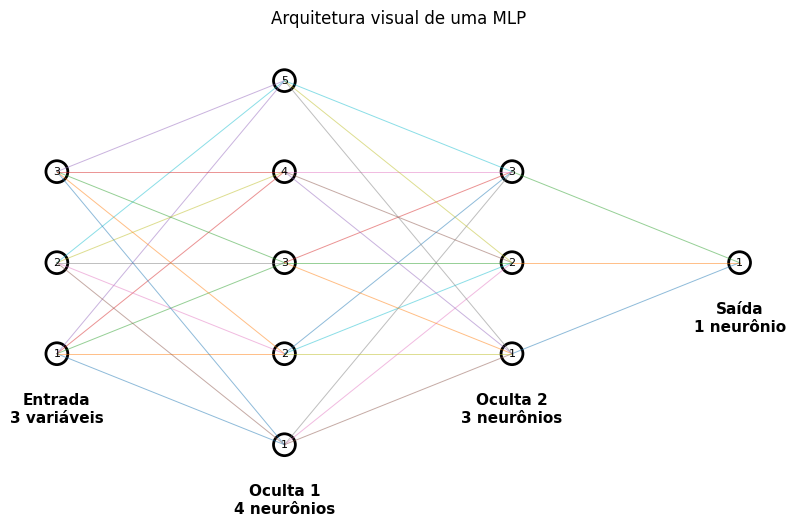

In [5]:
# Função para desenhar uma arquitetura MLP simples
def desenhar_mlp(tamanho_camadas, nomes_camadas=None):
    plt.figure(figsize=(10, 6))

    if nomes_camadas is None:
        nomes_camadas = [f'Camada {i}' for i in range(len(tamanho_camadas))]

    espacamento_x = 2.5
    raio = 0.12
    posicoes = []

    for i, n_neuronios in enumerate(tamanho_camadas):
        x = i * espacamento_x
        y_inicio = -(n_neuronios - 1) / 2
        camada_pos = []

        for j in range(n_neuronios):
            y = y_inicio + j
            circulo = plt.Circle((x, y), raio, fill=False, linewidth=2)
            plt.gca().add_patch(circulo)
            plt.text(x, y, f'{j+1}', ha='center', va='center', fontsize=8)
            camada_pos.append((x, y))

        posicoes.append(camada_pos)
        plt.text(x, y_inicio - 0.75, nomes_camadas[i], ha='center', fontsize=11, fontweight='bold')

    for i in range(len(posicoes) - 1):
        for origem in posicoes[i]:
            for destino in posicoes[i + 1]:
                plt.plot([origem[0], destino[0]], [origem[1], destino[1]], linewidth=0.7, alpha=0.5)

    plt.axis('equal')
    plt.axis('off')
    plt.title('Arquitetura visual de uma MLP')
    plt.show()

# Complete a arquitetura da rede:
# Entrada: 3 variáveis
# Oculta 1: 4 neurônios
# Oculta 2: 3 neurônios
# Saída: 1 neurônio
desenhar_mlp(
    tamanho_camadas=[3,5,3,1],
    nomes_camadas=['Entrada\n3 variáveis', 'Oculta 1\n4 neurônios', 'Oculta 2\n3 neurônios', 'Saída\n1 neurônio']
)

## 4. Preparando os dados para a MLP

Complete a separação entre entradas e saída.

Lembre-se:

- Entradas: temperatura, vibração e corrente.
- Saída: risco de falha.

In [6]:
# Complete as colunas de entrada e saída
X = df[['temperatura_motor_c', 'vibracao_mm_s', 'corrente_a']]
y = df['risco_falha']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Exemplo de dados originais:')
display(X_train.head())

print('\nExemplo de dados padronizados:')
print(X_train_scaled[:5])

Exemplo de dados originais:


,temperatura_motor_c,vibracao_mm_s,corrente_a
155,56.43,2.08,7.48
8,59.37,2.14,7.47
63,50.65,1.51,9.63
23,47.90,4.04,8.93
34,74.87,1.18,11.79



Exemplo de dados padronizados:
[[-0.73139005 -0.80013716 -0.42672803]
 [-0.47534257 -0.74956992 -0.4315619 ]
 [-1.23477591 -1.28052592  0.61255364]
 [-1.47427611  0.85172596  0.27418287]
 [ 0.87456762 -1.55864573  1.65666918]]


## 5. Forward Propagation

Complete as funções de ativação.

A função ReLU retorna zero para valores negativos e mantém valores positivos.

A função Sigmoid transforma qualquer valor em uma saída entre 0 e 1.

In [7]:
def relu(z):
    return np.maximum(0, z)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def tanh(z):
    return np.tanh(z)

## 6. Forward propagation manual com NumPy

Complete os pontos principais da propagação direta.

In [8]:
# Selecionar uma amostra do dataset
x_exemplo = X_train_scaled[0].reshape(1, -1)

print('Amostra de entrada padronizada:')
print(x_exemplo)

# Pesos e vieses definidos manualmente para demonstração
W1 = np.array([
    [ 0.6, -0.2,  0.4,  0.1],
    [ 0.3,  0.8, -0.5,  0.7],
    [-0.4,  0.2,  0.9, -0.3]
])

b1 = np.array([[0.1, -0.1, 0.05, 0.2]])

W2 = np.array([
    [ 0.5, -0.3,  0.8],
    [-0.6,  0.7,  0.2],
    [ 0.1,  0.4, -0.5],
    [ 0.9, -0.2,  0.3]
])

b2 = np.array([[0.05, 0.1, -0.05]])

W3 = np.array([
    [0.7],
    [-0.4],
    [0.9]
])

b3 = np.array([[0.1]])

# Complete a propagação direta
z1 = np.dot(x_exemplo, W1) + b1
a1 = relu(z1)

z2 = np.dot(a1, W2) + b2
a2 = relu(z2)

z3 = np.dot(a2, W3) + b3
saida = sigmoid(z3)

print('\nZ1 - soma ponderada da camada oculta 1:')
print(z1)

print('\nA1 - saída da camada oculta 1 após ReLU:')
print(a1)

print('\nZ2 - soma ponderada da camada oculta 2:')
print(z2)

print('\nA2 - saída da camada oculta 2 após ReLU:')
print(a2)

print('\nZ3 - soma ponderada da saída:')
print(z3)

print('\nSaída final após Sigmoid:')
print(saida)

print(f'\nProbabilidade estimada de risco de falha: {saida[0][0]:.2%}')

Amostra de entrada padronizada:
[[-0.73139005 -0.80013716 -0.42672803]]

Z1 - soma ponderada da camada oculta 1:
[[-0.40818397 -0.67917732 -0.22654266 -0.30521661]]

A1 - saída da camada oculta 1 após ReLU:
[[0. 0. 0. 0.]]

Z2 - soma ponderada da camada oculta 2:
[[ 0.05  0.1  -0.05]]

A2 - saída da camada oculta 2 após ReLU:
[[0.05 0.1  0.  ]]

Z3 - soma ponderada da saída:
[[0.095]]

Saída final após Sigmoid:
[[0.52373215]]

Probabilidade estimada de risco de falha: 52.37%


In [9]:
# Complete o dicionário com as etapas do fluxo
fluxo = {
    'Entrada padronizada': x_exemplo.flatten(),
    'Camada oculta 1 - z1': z1.flatten(),
    'Camada oculta 1 - a1': a1.flatten(),
    'Camada oculta 2 - z2': z2.flatten(),
    'Camada oculta 2 - a2': a2.flatten(),
    'Saída final': saida.flatten()
}

for etapa, valores in fluxo.items():
    print(f'\n{etapa}:')
    print(np.round(valores, 4))


Entrada padronizada:
[-0.7314 -0.8001 -0.4267]

Camada oculta 1 - z1:
[-0.4082 -0.6792 -0.2265 -0.3052]

Camada oculta 1 - a1:
[0. 0. 0. 0.]

Camada oculta 2 - z2:
[ 0.05  0.1  -0.05]

Camada oculta 2 - a2:
[0.05 0.1  0.  ]

Saída final:
[0.5237]


<BarContainer object of 3 artists>

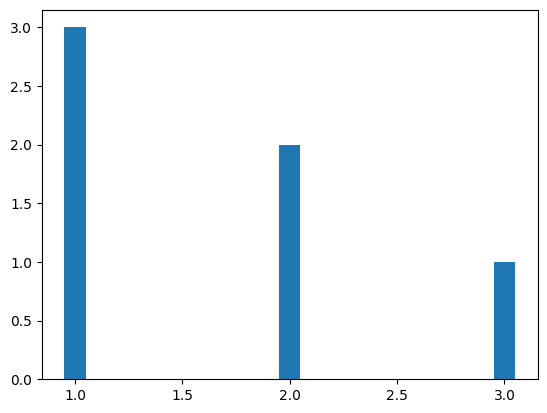

In [10]:
range(len(a2.flatten()))
plt.bar([1,2,3],[3,2,1], width=0.1)

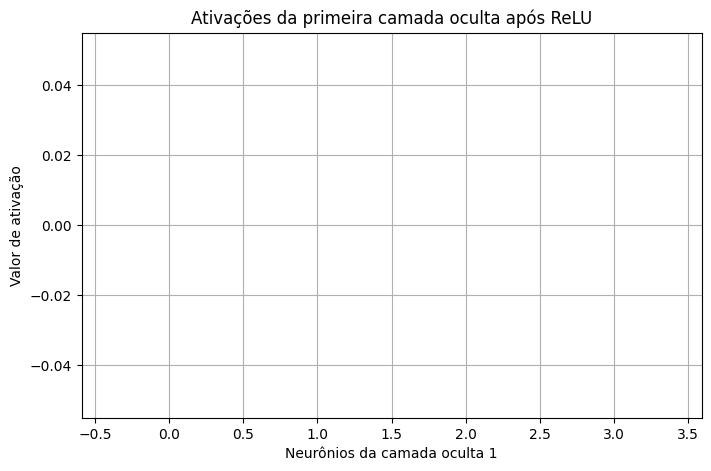

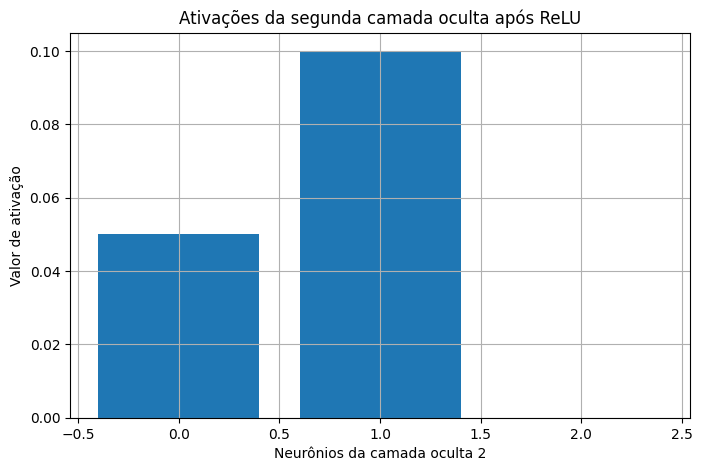

In [11]:
# Gráfico dos valores de ativação por camada
plt.figure(figsize=(8, 5))
plt.bar(range(len(a1.flatten())), a1.flatten())
plt.title('Ativações da primeira camada oculta após ReLU')
plt.xlabel('Neurônios da camada oculta 1')
plt.ylabel('Valor de ativação')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(range(len(a2.flatten())), a2.flatten())
plt.title('Ativações da segunda camada oculta após ReLU')
plt.xlabel('Neurônios da camada oculta 2')
plt.ylabel('Valor de ativação')
plt.grid(True)
plt.show()




## 7. Implementando a MLP para várias amostras

Complete a função `forward_mlp`.

In [12]:
def forward_mlp(X):
    z1 = np.dot(X, W1) + b1
    a1 = relu(z1)

    z2 = np.dot(a1, W2) + b2
    a2 = relu(z2)

    z3 = np.dot(a2, W3) + b3
    saida = sigmoid(z3)

    return saida

probabilidades = forward_mlp(X_test_scaled)
predicoes = (probabilidades >= 0.5).astype(int).flatten()

print('Primeiras probabilidades:')
print(np.round(probabilidades[:10].flatten(), 4))

print('\nPrimeiras predições:')
print(predicoes[:10])

print('\nAcurácia com pesos manuais, ainda sem treinamento:')
print(accuracy_score(y_test, predicoes))

Primeiras probabilidades:
[0.5795 0.5625 0.7942 0.5173 0.4694 0.5382 0.7046 0.5005 0.5186 0.4951]

Primeiras predições:
[1 1 1 1 0 1 1 1 1 0]

Acurácia com pesos manuais, ainda sem treinamento:
0.34545454545454546


## 8. MLP treinada com Scikit-learn

Complete os principais parâmetros da MLP.

In [13]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(4, 3),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42
)

mlp.fit(X_train_scaled, y_train)

y_pred = mlp.predict(X_test_scaled)

print('Acurácia da MLP treinada:')
print(accuracy_score(y_test, y_pred))

print('\nMatriz de confusão:')
print(confusion_matrix(y_test, y_pred))

print('\nRelatório de classificação:')
print(classification_report(y_test, y_pred))

Acurácia da MLP treinada:
0.7636363636363637

Matriz de confusão:
[[30  8]
 [ 5 12]]

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.86      0.79      0.82        38
           1       0.60      0.71      0.65        17

    accuracy                           0.76        55
   macro avg       0.73      0.75      0.74        55
weighted avg       0.78      0.76      0.77        55



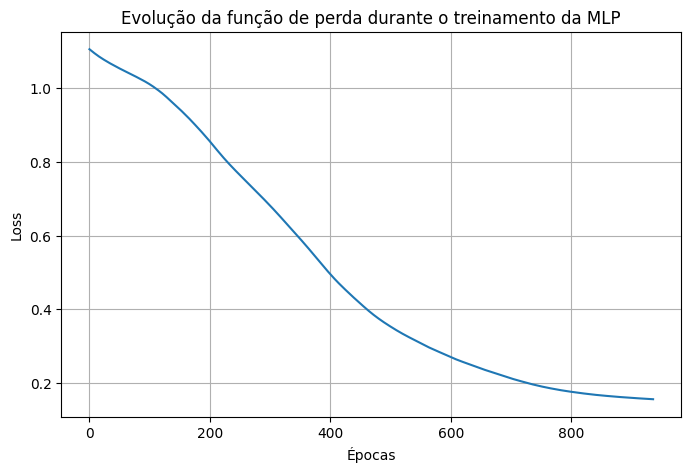

In [14]:
# Visualização da evolução da loss durante o treinamento
plt.figure(figsize=(8, 5))
plt.plot(mlp.loss_curve_)
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.title('Evolução da função de perda durante o treinamento da MLP')
plt.grid(True)
plt.show()

## 9. Atividade avaliativa da aula

Responda tecnicamente:

1. Quais são as três camadas principais de uma MLP?
2. Qual é o papel da camada oculta?
3. O que acontece na etapa de forward propagation?
4. Por que a função ReLU foi usada nas camadas ocultas?
5. Por que a função Sigmoid foi usada na saída?
6. Qual a diferença entre a rede com pesos manuais e a rede treinada?
7. O que a curva de loss indica sobre o treinamento?

**Respostas do aluno:**

1.  As três camadas principais de uma MLP são:
Camada de entrada (Input Layer)
Camada oculta (Hidden Layer)
Camada de saída (Output Layer)

2.  Papel da camada oculta (Hidden Layer):
A camada oculta é responsável por processar as informações da rede neural, realizando os cálculos que permitem aprender padrões nos dados.
🔹 Função técnica:
Executar a soma ponderada (pesos + bias)
Aplicar uma função de ativação (ReLU, Sigmoid, etc.)
Transformar os dados em representações mais complexas
🔹 Importância:
É onde ocorre o aprendizado real do modelo
Permite identificar relações não lineares
Quanto mais camadas ocultas, maior a capacidade de resolver problemas complexos

3.  Forward Propagation (Propagação Direta):
É a etapa em que os dados percorrem a rede neural do início ao fim, passando pela entrada, camadas ocultas e chegando à saída.

🔹 O que acontece nessa etapa:
Os dados de entrada são inseridos na rede
Cada neurônio calcula a soma ponderada (entrada × pesos + bias)
O resultado passa por uma função de ativação
Os valores seguem para a próxima camada
Ao final, é gerada a saída (previsão)

🔹 Resumo técnico:
Entrada → cálculos nas camadas → ativação → propagação → saída final

🔹 Resumo direto:
Na forward propagation, a rede neural transforma dados de entrada em uma previsão, aplicando pesos, bias e funções de ativação ao longo das camadas.

💡 Exemplo:
Em um sistema de classificação:
Entrada: dados de um cliente
Saída: Aprovado ou Reprovado
A forward propagation é o momento em que essa decisão é calculada.

4.  A função ReLU (Rectified Linear Unit) é utilizada nas camadas ocultas porque melhora o desempenho e a eficiência do aprendizado da rede neural.

🔹 Principais motivos técnicos:
Introduz não linearidade
Permite que a rede aprenda relações complexas entre os dados (não lineares).
Reduz o problema do gradiente desaparecendo
Diferente de outras funções (como sigmoid), mantém gradientes maiores, facilitando o treinamento.
Alta eficiência computacional
Cálculo simples:
ReLU(x) = max(0, x)

Isso torna o processamento mais rápido.
Evita saturação positiva
Para valores positivos, a saída cresce linearmente, ajudando no aprendizado.

🔹 Resumo direto:
A ReLU é usada porque torna o treinamento mais rápido, estável e eficiente, além de permitir que a rede aprenda padrões complexos.

💡 Exemplo:
Se um neurônio recebe valores negativos (sem relevância), a ReLU zera esses valores, mantendo apenas os sinais importantes para o aprendizado.

5.  Por que a função Sigmoid foi usada na saída?
A função Sigmoid é utilizada na camada de saída principalmente quando o problema envolve classificação binária.

🔹 Principais motivos técnicos:
Gera valores entre 0 e 1
A saída da Sigmoid está no intervalo:
0 ≤ f(x) ≤ 1

Isso permite interpretar o resultado como probabilidade.
Adequada para classificação binária
Facilita decisões como:
0 → Classe negativa
1 → Classe positiva

Interpretação simples
Exemplo:
0.85 → 85% de chance de pertencer à classe

🔹 Resumo direto:
A Sigmoid é usada na saída porque transforma o resultado da rede em uma probabilidade, ideal para decisões como sim/não, verdadeiro/falso, aprovado/reprovado.

💡 Exemplo:
Em um sistema de detecção de falhas:
Saída = 0.92 → alta probabilidade de falha
Saída = 0.10 → baixa probabilidade de falha
✅ Conclusão:
A função Sigmoid é ideal na saída porque padroniza o resultado e facilita a tomada de decisão em problemas de classificação binária.

6.  🔹 Rede com pesos manuais:
Os pesos são definidos manualmente pelo usuário/programador
Não há aprendizado automático
Funciona apenas para casos simples ou testes
Não se adapta a novos dados
Pode gerar resultados imprecisos

🔹 Rede treinada:
Os pesos são ajustados automaticamente durante o treinamento
Usa algoritmos como backpropagation
Aprende padrões a partir dos dados
Se adapta e melhora com mais exemplos
Apresenta maior precisão e capacidade de generalização

🔹 Resumo direto:
Pesos manuais → definidos pelo humano, sem aprendizado
Rede treinada → aprende sozinha ajustando os pesos com base nos dados

💡 Exemplo:
Pesos manuais: você tenta “adivinhar” como a rede deve decidir
Rede treinada: a própria rede aprende com os dados e melhora suas decisões automaticamente

✅ Conclusão:
A rede treinada é muito mais eficiente, pois consegue aprender, evoluir e se adaptar, enquanto a rede com pesos manuais é limitada e não escalável.

7.Curva de loss (função de perda) no treinamento:
A curva de loss indica o erro do modelo ao longo do treinamento, mostrando o quanto a rede neural está aprendendo.
🔹 O que a curva representa:
Eixo X → épocas (iterações de treinamento)
Eixo Y → valor do erro (loss)

🔹 Interpretação:
Loss diminuindo 📉
→ O modelo está aprendendo corretamente
→ As previsões estão ficando mais precisas

Loss estável (parando de cair)
→ O modelo pode ter atingido um limite de aprendizado
→ Pode indicar necessidade de ajustes

Loss aumentando 📈
→ O modelo está aprendendo errado
→ Possível problema (taxa de aprendizado, dados, etc.)

Diferença entre treino e validação
→ Se o treino melhora e a validação piora: overfitting

🔹 Resumo direto:
A curva de loss mostra se o modelo está melhorando ou não durante o treinamento.

💡 Exemplo:
Início: loss = 0.8
Meio: loss = 0.3
Final: loss = 0.1

✅ Isso indica que o modelo aprendeu e reduziu o erro com o tempo.

✅ Conclusão:
A curva de loss é uma ferramenta essencial para monitorar, avaliar e ajustar o treinamento de modelos de IA.
Forneça seus comentários sobre o BizChat